# 04 Manager Dashboard Views

Manager/Admin-facing visualization notebook for demand forecasting and inventory recommendations.

Data source: `modeling/outputs/reports/*.csv`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

REPORT_DIR = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports')
fc = pd.read_csv(REPORT_DIR / 'dashboard_forecast_output.csv')
inv = pd.read_csv(REPORT_DIR / 'dashboard_inventory_recommendations.csv')
lb = pd.read_csv(REPORT_DIR / 'leaderboard_top5_per_dataset.csv')
byh = pd.read_csv(REPORT_DIR / 'test_metrics_by_horizon.csv')

fc['month'] = pd.to_datetime(fc['month'])
print('Forecast rows:', len(fc))
print('Inventory rows:', len(inv))
print('Datasets:', sorted(fc['dataset'].unique()))
print('Models:', sorted(fc['model'].unique()))


Forecast rows: 19872
Inventory rows: 2620
Datasets: ['A', 'B', 'C']
Models: ['ARIMA', 'CATBOOST', 'ETS', 'SARIMA', 'XGBOOST']


## 1) Leaderboard (What model is best?)


,dataset,model,WAPE,MASE_mean,RMSE,Bias,under_forecast_rate
0,A,CATBOOST,0.090527,0.876032,4318.904070,-309.061924,0.475728
1,A,XGBOOST,0.093703,0.877113,4472.223517,-149.930867,0.460626
2,A,ETS,0.106712,0.942027,4981.780602,-182.469029,0.501618
5,B,CATBOOST,0.090447,0.874679,4308.729631,-68.675493,0.466019
6,B,XGBOOST,0.092755,0.878629,4458.406145,-158.650058,0.490831
7,B,ETS,0.106712,0.942027,4981.780602,-182.469029,0.501618
10,C,CATBOOST,0.156308,1.006894,7708.788871,543.816570,0.419567
11,C,XGBOOST,0.160976,1.012095,7925.859992,706.929678,0.428791


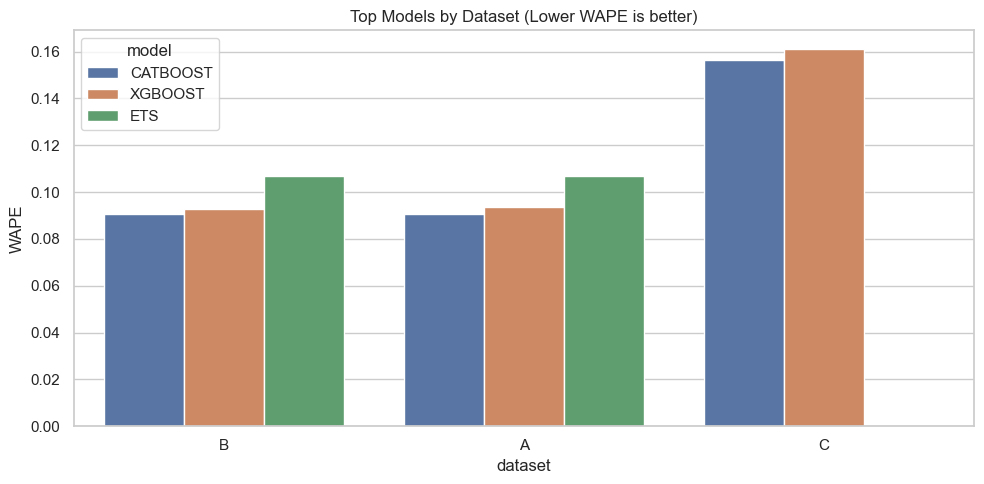

In [2]:
best = lb.sort_values(['dataset','WAPE']).groupby('dataset', as_index=False).head(3)
display(best[['dataset','model','WAPE','MASE_mean','RMSE','Bias','under_forecast_rate']].sort_values(['dataset','WAPE']))

plt.figure(figsize=(10,5))
sns.barplot(data=best.sort_values('WAPE'), x='dataset', y='WAPE', hue='model')
plt.title('Top Models by Dataset (Lower WAPE is better)')
plt.tight_layout()
plt.show()


## 2) Multi-Horizon Accuracy (H+1 / H+2 / H+3)


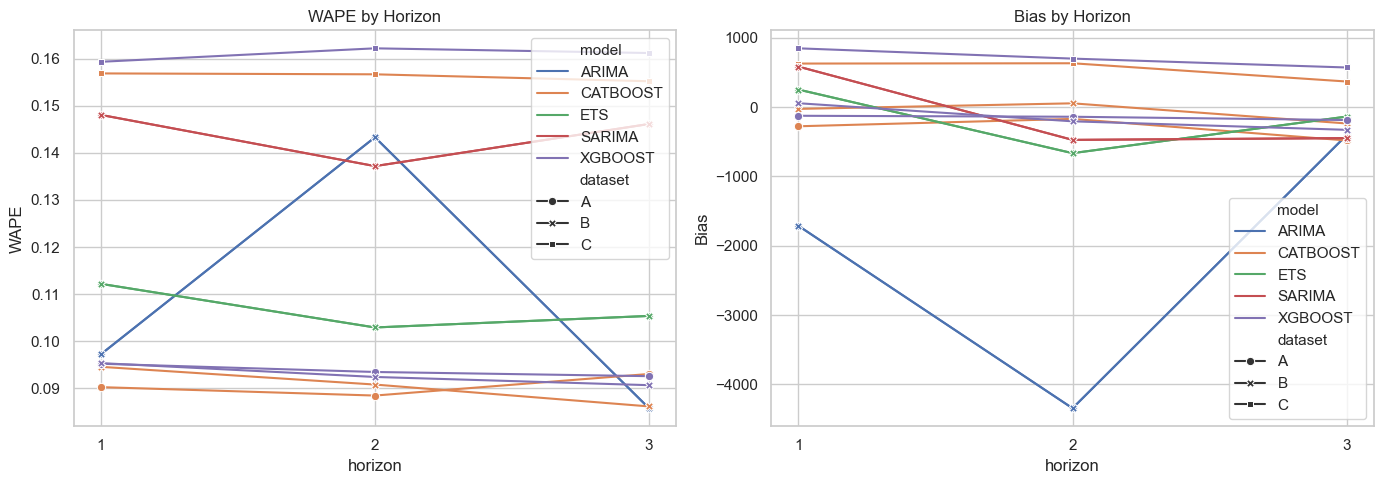

In [3]:
h = byh[byh['horizon'].isin([1,2,3])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.lineplot(data=h, x='horizon', y='WAPE', hue='model', style='dataset', markers=True, dashes=False, ax=axes[0])
axes[0].set_title('WAPE by Horizon')
axes[0].set_xticks([1,2,3])

sns.lineplot(data=h, x='horizon', y='Bias', hue='model', style='dataset', markers=True, dashes=False, ax=axes[1])
axes[1].set_title('Bias by Horizon')
axes[1].set_xticks([1,2,3])

plt.tight_layout()
plt.show()


## 3) Demand Forecast View (P50 + Uncertainty Band)
Pick any dataset/model/SKU for manager review.


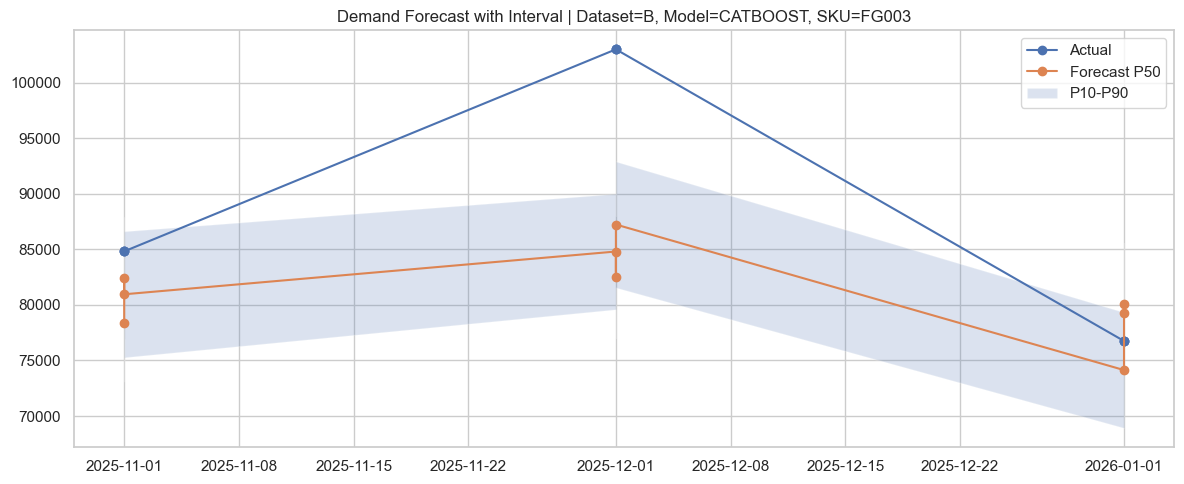

,month,horizon,y_true,forecast_p50,p10,p90
2787,2025-11-01,1,84830.0,78354.612212,73147.445030,83561.779394
3096,2025-11-01,2,84830.0,82389.220024,76903.427524,87875.012525
3405,2025-11-01,3,84830.0,80963.881721,75285.418309,86642.345133
2788,2025-12-01,1,103028.0,84816.833120,79609.665938,90024.000301
3097,2025-12-01,2,103028.0,82548.438125,77062.645624,88034.230625
3406,2025-12-01,3,103028.0,87246.921626,81568.458215,92925.385038
2789,2026-01-01,1,76755.0,74137.374529,68930.207347,79344.541711
3098,2026-01-01,2,76755.0,80055.271901,74569.479401,85541.064402
3407,2026-01-01,3,76755.0,79302.336062,73623.872650,84980.799474


In [4]:
dataset_sel = 'B'
model_sel = 'CATBOOST'

sub = fc[(fc['dataset']==dataset_sel) & (fc['model']==model_sel)].copy()

# choose top SKU by demand for this model/dataset
sku = sub.groupby('fg_code')['y_true'].sum().sort_values(ascending=False).index[0]
ss = sub[sub['fg_code']==sku].sort_values(['month','horizon'])

plt.figure(figsize=(12,5))
plt.plot(ss['month'], ss['y_true'], marker='o', label='Actual')
plt.plot(ss['month'], ss['forecast_p50'], marker='o', label='Forecast P50')
plt.fill_between(ss['month'], ss['p10'], ss['p90'], alpha=0.2, label='P10-P90')
plt.title(f'Demand Forecast with Interval | Dataset={dataset_sel}, Model={model_sel}, SKU={sku}')
plt.legend()
plt.tight_layout()
plt.show()

display(ss[['month','horizon','y_true','forecast_p50','p10','p90']].head(15))


## 4) Inventory Action View (ROP, Safety Stock, Suggested Order)


,fg_code,fg_category,forecast_p50,on_hand_inventory,safety_stock,reorder_point,target_max,suggested_order_qty
211,FG006,Soap,68303.085859,93012.0,16915.0,98879.0,167182.0,74170.0
254,FG049,Diaper,65086.470394,85596.0,10913.0,71660.0,136746.0,51150.0
257,FG052,Diaper,65192.958335,77005.0,8598.0,52060.0,117253.0,40248.0
240,FG035,Liquid Wash,42280.186823,60912.0,10767.0,58685.0,100965.0,40053.0
226,FG021,Shampoo,41526.615629,41660.0,4152.0,35989.0,77516.0,35856.0
207,FG002,Soap,51797.168697,74976.0,7490.0,57561.0,109358.0,34382.0
268,FG063,Sanitary,45570.968437,53520.0,5025.0,39963.0,85534.0,32014.0
259,FG054,Diaper,64642.387721,95660.0,9685.0,61399.0,126041.0,30381.0
249,FG044,Diaper,45147.247939,51462.0,3872.0,35475.0,80622.0,29160.0
243,FG038,Liquid Wash,35512.689676,54765.0,5382.0,47997.0,83510.0,28745.0


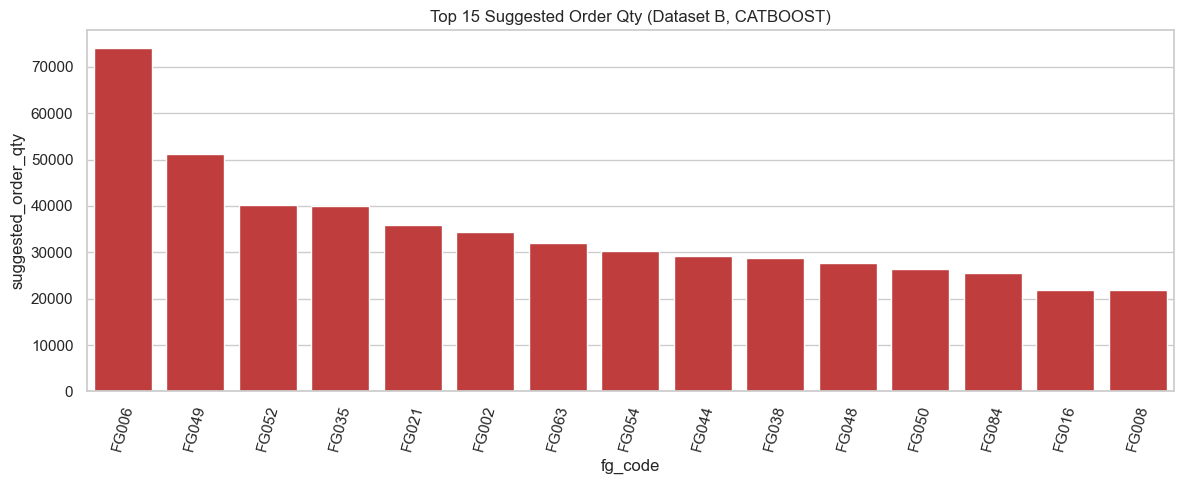

In [5]:
invb = inv[(inv['dataset']=='B') & (inv['model']=='CATBOOST')].copy()

# top actionable: largest suggested orders
actions = invb.sort_values('suggested_order_qty', ascending=False).head(25)
display(actions[['fg_code','fg_category','forecast_p50','on_hand_inventory','safety_stock','reorder_point','target_max','suggested_order_qty']])

plt.figure(figsize=(12,5))
sns.barplot(data=actions.head(15), x='fg_code', y='suggested_order_qty', color='#d62728')
plt.title('Top 15 Suggested Order Qty (Dataset B, CATBOOST)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 5) Risk View (Under-forecast / Over-forecast exposure)


,dataset,model,risk_type,total_abs_error,avg_error
3,A,CATBOOST,Under-forecast,1.505614e+06,-3414.091657
9,A,XGBOOST,Under-forecast,1.479646e+06,-3465.213299
8,A,XGBOOST,Over-forecast,1.340660e+06,2681.320330
2,A,CATBOOST,Over-forecast,1.219114e+06,2508.465057
1,A,ARIMA,Under-forecast,8.845759e+05,-4192.302704
7,A,SARIMA,Under-forecast,7.377033e+05,-5307.217862
6,A,SARIMA,Over-forecast,7.031875e+05,4136.396958
5,A,ETS,Under-forecast,5.635020e+05,-3635.496554
4,A,ETS,Over-forecast,5.071190e+05,3292.980751
0,A,ARIMA,Over-forecast,2.188627e+05,2233.293183


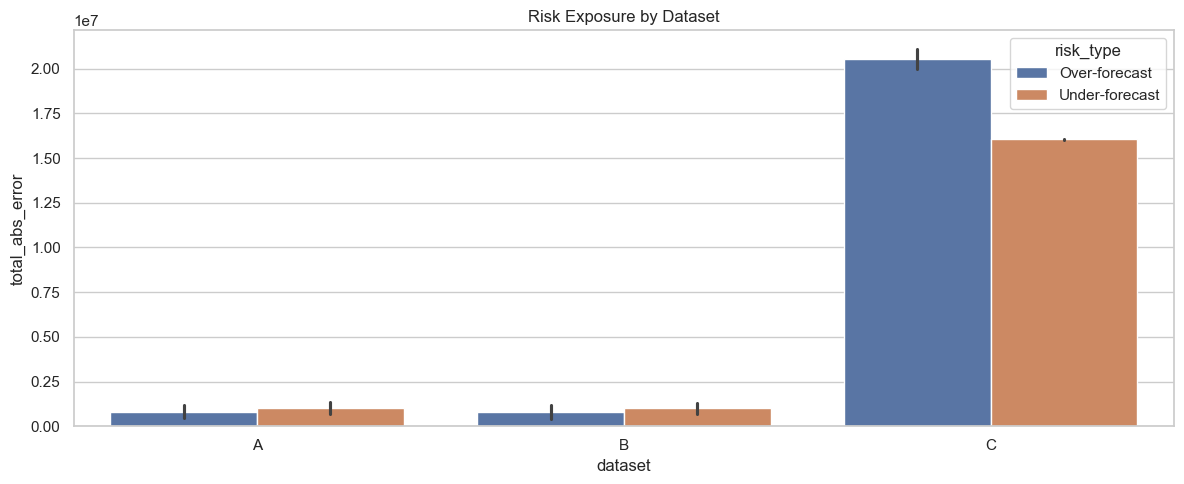

In [6]:
r = fc.copy()
r['error'] = r['forecast_p50'] - r['y_true']
r['abs_error'] = r['error'].abs()
r['risk_type'] = np.where(r['error'] < 0, 'Under-forecast', 'Over-forecast')

risk = (r.groupby(['dataset','model','risk_type'], as_index=False)
          .agg(total_abs_error=('abs_error','sum'), avg_error=('error','mean')))

display(risk.sort_values(['dataset','total_abs_error'], ascending=[True,False]))

plt.figure(figsize=(12,5))
sns.barplot(data=risk, x='dataset', y='total_abs_error', hue='risk_type')
plt.title('Risk Exposure by Dataset')
plt.tight_layout()
plt.show()


## 6) Export Manager Summary Tables


In [7]:
summary_dir = REPORT_DIR

# model summary per dataset
model_summary = lb.sort_values(['dataset','WAPE']).groupby('dataset', as_index=False).head(1)
model_summary.to_csv(summary_dir / 'manager_model_summary.csv', index=False)

# inventory priority list
inv_priority = inv.sort_values('suggested_order_qty', ascending=False).head(200)
inv_priority.to_csv(summary_dir / 'manager_inventory_priority_top200.csv', index=False)

# risk summary
risk_summary = risk.copy()
risk_summary.to_csv(summary_dir / 'manager_risk_summary.csv', index=False)

print('Saved:')
print(summary_dir / 'manager_model_summary.csv')
print(summary_dir / 'manager_inventory_priority_top200.csv')
print(summary_dir / 'manager_risk_summary.csv')


Saved:
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_model_summary.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_inventory_priority_top200.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_risk_summary.csv
